In [96]:
# !pip install shap
import shap
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt
import keras_tuner as kt
import os

In [97]:
df_train = pd.read_csv('../train_set/train_cleaned_outliers.csv')
df_train = df_train.drop('originalTitle', axis=1)
df_train = df_train.drop('averageRating', axis=1)

df_test = pd.read_csv('../test_set/test_no_title.csv')
df_test = df_test.drop('averageRating', axis=1)


In [98]:
# change all 1, 2, 3 in 4
df_train['rating'] = df_train['rating'].replace([1, 2, 3], 4)
df_test['rating'] = df_test['rating'].replace([1, 2, 3], 4)

# replace all 10 with 9
df_train['rating'] = df_train['rating'].replace(10, 9)
df_test['rating'] = df_test['rating'].replace(10, 9)

In [99]:
# Supponendo che df_train e df_test siano i tuoi DataFrame
label_mapping = {4: 0, 5: 1, 6: 2, 7: 3, 8: 4, 9: 5}

df_train['rating'] = df_train['rating'].map(label_mapping)
df_test['rating'] = df_test['rating'].map(label_mapping)

# Verifica che tutte le etichette siano state mappate correttamente
assert df_train['rating'].isnull().sum() == 0, "Alcune etichette di training non sono state mappate correttamente."
assert df_test['rating'].isnull().sum() == 0, "Alcune etichette di test non sono state mappate correttamente."


In [100]:
# train and test splits

X_train = df_train.drop(columns=['rating'])
y_train = df_train['rating'] 

X_test = df_test.drop(columns=['rating', 'genreShort'])
y_test = df_test['rating']

X_train.head()

,numVotes,totalCredits,criticReviewsTotal,titleType,userReviewsTotal,castNumber,companiesNumber,writerCredits,directorsCredits,quotesTotal,...,genreMystery,genreHistory,genreSci-Fi,genreAnimation,genreAdventure,genreReality-TV,genreMusical,genreThriller,genreGame-Show,genreCrime
0,13,4,0,1,0,3,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,15,37,2,1,0,17,5,2,1,0,...,0,0,0,0,0,0,0,0,0,0
2,12,13,0,3,0,13,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,7,60,0,3,0,31,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,12,103,0,3,0,22,2,10,1,0,...,0,1,0,0,1,0,0,0,0,0


In [101]:
 # useremo os per costruire il percorso in modo robusto

# Definisci il percorso della cartella in cui si trova il tuo modello
# Questa è la cartella 'Downloads' nel tuo utente specifico
directory_path = '../03_Classification/models/NN_rating_classifier/'

# Definisci il nome del file del tuo modello
model_filename = 'NN_rating_classifier.h5'

# Combina il percorso della directory con il nome del file
# os.path.join() è il modo migliore per farlo, perché gestisce automaticamente
# i separatori di percorso (es. '/' su macOS/Linux, '\' su Windows)
full_model_path = os.path.join(directory_path, model_filename)

print(f"Tentativo di caricare il modello da: {full_model_path}")

# Carica il modello
try:
    optimized_nn = keras.models.load_model(full_model_path)
    print("Modello caricato con successo!")

    # Ora puoi interagire con il tuo modello, ad esempio:
    # loaded_model.summary() # Per vedere la struttura del modello
    # predictions = loaded_model.predict(nuovi_dati) # Per fare previsioni

except FileNotFoundError:
    print(f"Errore: Il file '{model_filename}' non è stato trovato nel percorso specificato.")
    print(f"Assicurati che il file esista esattamente qui: {full_model_path}")
except Exception as e:
    print(f"Si è verificato un errore durante il caricamento del modello: {e}")

Tentativo di caricare il modello da: ../03_Classification/models/NN_rating_classifier/NN_rating_classifier.h5
Modello caricato con successo!


In [102]:
from sklearn.preprocessing import MinMaxScaler

# Inizializza lo scaler
scaler = MinMaxScaler()

# Applica la normalizzazione solo alle colonne numeriche
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ricostruisci DataFrame con i nomi delle colonne originali
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [103]:
optimized_nn.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 448)               18816     
                                                                 
 dropout_5 (Dropout)         (None, 448)               0         
                                                                 
 dense_8 (Dense)             (None, 128)               57472     
                                                                 
 dropout_6 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 48)                6192      
                                                                 
 dropout_7 (Dropout)         (None, 48)                0         
                                                                 
 dense_10 (Dense)            (None, 6)                

In [104]:
from sklearn.metrics import classification_report
y_pred = optimized_nn.predict(X_test_scaled)
optimized_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']  # Lista semplice, non annidata
)

optimized_nn.evaluate(X_test_scaled, y_test)

y_pred = optimized_nn.predict(X_test_scaled)

1135/1135 [==============================] - 1s 896us/step


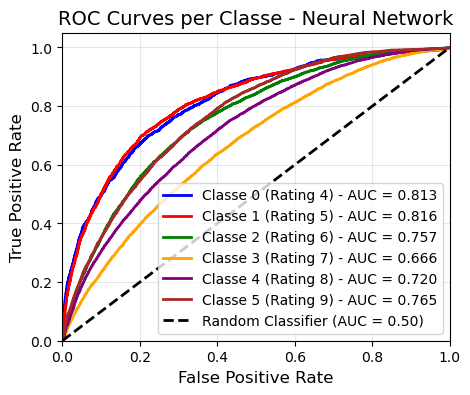


📊 AUC MEDIO: 0.7561
  Rating 4 (Classe 0): AUC = 0.813 - Buona
  Rating 5 (Classe 1): AUC = 0.816 - Buona
  Rating 6 (Classe 2): AUC = 0.757 - Discreta
  Rating 7 (Classe 3): AUC = 0.666 - Da migliorare
  Rating 8 (Classe 4): AUC = 0.720 - Discreta
  Rating 9 (Classe 5): AUC = 0.765 - Discreta

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0     0.3827    0.1157    0.1777      1184
           1     0.4588    0.1164    0.1857      2199
           2     0.3672    0.2756    0.3149      5090
           3     0.3865    0.3750    0.3807      9375
           4     0.4677    0.6671    0.5499     11892
           5     0.4095    0.3436    0.3736      6555

    accuracy                         0.4270     36295
   macro avg     0.4121    0.3156    0.3304     36295
weighted avg     0.4188    0.4270    0.4072     36295



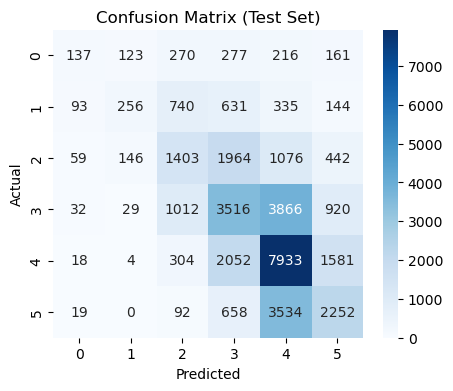

In [ ]:
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize

# USA LE PROBABILITÀ, NON LE CLASSI PREDETTE
y_pred_prob = optimized_nn.predict(X_test_scaled, verbose=0)  # Probabilità

# Binarizza le etichette 
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4, 5])
n_classes = y_test_bin.shape[1]

# Calcola ROC per ogni classe usando le PROBABILITÀ
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])  # ✅ Probabilità
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot migliorato
plt.figure(figsize=(5, 4))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'Classe {i} (Rating {i+4}) - AUC = {roc_auc[i]:.3f}')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves per Classe - Neural Network', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

# Calcola AUC medio
mean_auc = np.mean(list(roc_auc.values()))
print(f"\n📊 AUC MEDIO: {mean_auc:.4f}")

# Interpretazione AUC
for i, auc_score in roc_auc.items():
    rating = i + 4  # Converte indice a rating originale
    if auc_score > 0.9:
        performance = "Eccellente"
    elif auc_score > 0.8:
        performance = "Buona"
    elif auc_score > 0.7:
        performance = "Discreta"
    else:
        performance = "Da migliorare"
    
    print(f"  Rating {rating} (Classe {i}): AUC = {auc_score:.3f} - {performance}")

# Calcola le classi predette
y_pred_classes = np.argmax(y_pred_prob, axis=1)  # Classi predette

# classification report
print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_classes, digits=4))

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# SHAP

In [88]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin

# Applica KMeans per trovare i centroidi
kmeans = KMeans(n_clusters=2000, n_init=100, random_state=42, init='k-means++', tol=1e-3, verbose=1).fit(X_train_scaled)

# Ottieni i centroidi
centroids = kmeans.cluster_centers_

Initialization complete
Iteration 0, inertia 9733.796711885732.
Iteration 1, inertia 7554.779855023594.
Iteration 2, inertia 7380.511494348893.
Iteration 3, inertia 7318.279875196132.
Iteration 4, inertia 7280.167951424756.
Iteration 5, inertia 7257.650672445159.
Iteration 6, inertia 7242.202683213791.
Iteration 7, inertia 7230.701917502885.
Iteration 8, inertia 7224.137615952528.
Iteration 9, inertia 7218.481376389118.
Iteration 10, inertia 7214.4149228787555.
Iteration 11, inertia 7211.91707295081.
Iteration 12, inertia 7209.895695285045.
Iteration 13, inertia 7208.1519971478665.
Iteration 14, inertia 7206.75141109335.
Iteration 15, inertia 7205.2963409228105.
Iteration 16, inertia 7203.945840507542.
Iteration 17, inertia 7203.05523495409.
Iteration 18, inertia 7202.548794209733.
Iteration 19, inertia 7202.2506515174555.
Iteration 20, inertia 7201.938451046048.
Iteration 21, inertia 7201.534470621098.
Iteration 22, inertia 7201.110437806198.
Iteration 23, inertia 7200.715819750379.
I

KeyError: "None of [Index([ 9486,  2719, 35868, 63168, 58183, 61441, 37649, 33796, 58592, 70778,\n       ...\n       85896, 58282, 47056, 50244,  8473, 73922, 19622, 34749, 74287, 74266],\n      dtype='int64', length=2000)] are in the [columns]"

In [ ]:
# Trova il punto più vicino a ciascun centroide
closest_points_indices = pairwise_distances_argmin(centroids, X_train_scaled)

# Ottieni i punti reali più vicini ai centroidi
background = X_train_scaled.iloc[closest_points_indices]
background = background.values



In [ ]:
# # Stratified sampling (5000 samples) for test set
# _, test_samples, _, _ = train_test_split(X_test_scaled, y_test, test_size=2000, stratify=y_test, random_state=42)

# # optimized DeepExplainer (best choice for deep learning models)
# explainer = shap.DeepExplainer(optimized_nn, background)


In [113]:
import numpy as np
import pandas as pd

# Calcola le predizioni del modello
y_pred_classes = np.argmax(optimized_nn.predict(X_test_scaled), axis=1)

# Calcola la distanza tra la classe reale e quella predetta
errors = np.abs(y_test - y_pred_classes)

# Filtra i campioni con errori significativi (ad esempio, distanza > 1)
significant_errors_mask = errors > 1
test_samples = X_test_scaled[significant_errors_mask]
test_labels = y_test[significant_errors_mask]

print(f"Numero di campioni con errori significativi: {len(test_samples)}")

1135/1135 [==============================] - 1s 617us/step
Numero di campioni con errori significativi: 5687


In [114]:
print("Shape del background:", background.shape)
print("Shape dell'input del modello:", optimized_nn.input_shape)

Shape del background: (2000, 41)
Shape dell'input del modello: (None, 41)


In [115]:
explainer = shap.DeepExplainer(optimized_nn, background)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


In [116]:
# Usa questi campioni per il calcolo dei valori SHAP
batch_size = 100

# Converti in NumPy array prima del loop
test_samples_array = test_samples.values if isinstance(test_samples, pd.DataFrame) else test_samples

shap_values_list = []

for i in range(0, len(test_samples_array), batch_size):
    batch = test_samples_array[i:i + batch_size]  # Usa array NumPy
    batch_shap = explainer.shap_values(batch)
    shap_values_list.append(batch_shap)
    print("Batch ", i, " processed")

# Concatena correttamente
if isinstance(shap_values_list[0], list):  # Multi-classe
    shap_values = []
    for class_idx in range(len(shap_values_list[0])):  # Per ogni classe
        class_shap = [batch[class_idx] for batch in shap_values_list]
        shap_values.append(np.concatenate(class_shap, axis=0))
else:  # Singola classe o problema binario
    shap_values = np.concatenate(shap_values_list, axis=0)

print(f"SHAP values shape: {[sv.shape for sv in shap_values] if isinstance(shap_values, list) else shap_values.shape}")

/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/keras/backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


Batch  0  processed
Batch  100  processed
Batch  200  processed
Batch  300  processed
Batch  400  processed
Batch  500  processed
Batch  600  processed
Batch  700  processed
Batch  800  processed
Batch  900  processed
Batch  1000  processed
Batch  1100  processed
Batch  1200  processed
Batch  1300  processed
Batch  1400  processed
Batch  1500  processed
Batch  1600  processed
Batch  1700  processed
Batch  1800  processed
Batch  1900  processed
Batch  2000  processed
Batch  2100  processed
Batch  2200  processed
Batch  2300  processed
Batch  2400  processed
Batch  2500  processed
Batch  2600  processed
Batch  2700  processed
Batch  2800  processed
Batch  2900  processed
Batch  3000  processed
Batch  3100  processed
Batch  3200  processed
Batch  3300  processed
Batch  3400  processed
Batch  3500  processed
Batch  3600  processed
Batch  3700  processed
Batch  3800  processed
Batch  3900  processed
Batch  4000  processed
Batch  4100  processed
Batch  4200  processed
Batch  4300  processed


In [117]:
# Converti nel formato richiesto da SHAP plots
shap_values_formatted = []
for class_idx in range(6):
    shap_values_formatted.append(shap_values[:, :, class_idx])  # (2000, 42) per ogni classe

print(f"Formato per visualizzazione: {[sv.shape for sv in shap_values_formatted]}")

Formato per visualizzazione: [(5687, 41), (5687, 41), (5687, 41), (5687, 41), (5687, 41), (5687, 41)]


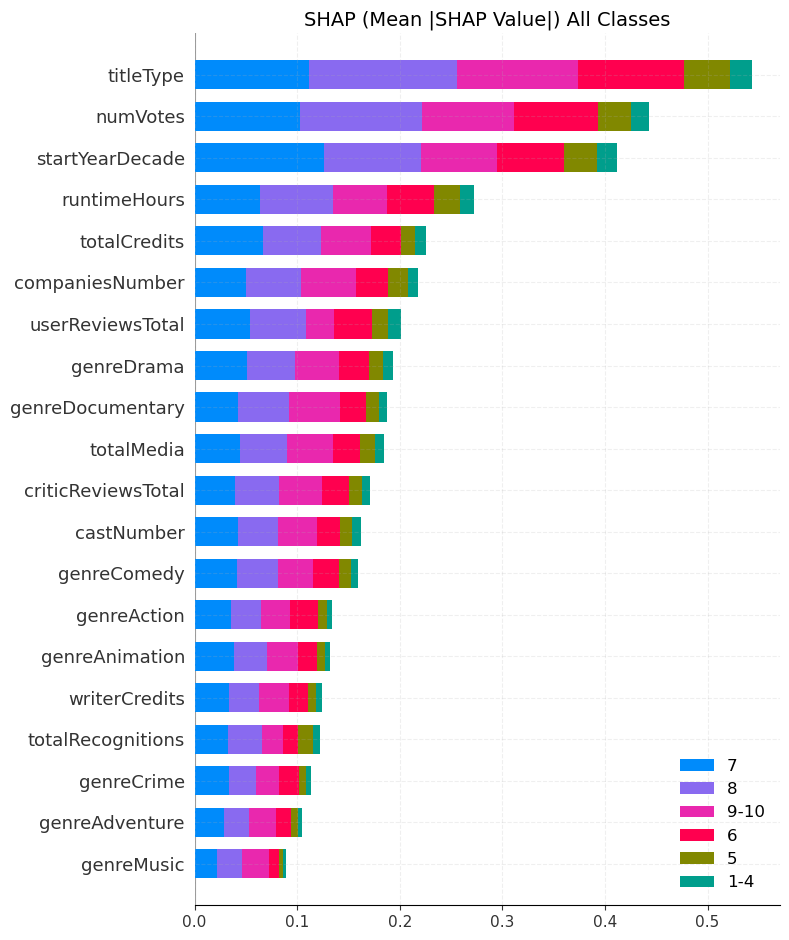

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correzione della mappa delle etichette
label_map = {
    0: "1-4",
    1: "5",
    2: "6",
    3: "7",
    4: "8",
    5: "9-10"
}

# Miglioramento del layout e dei colori
plt.figure(figsize=(10, 6))  # Dimensioni più compatte
shap.summary_plot(
    shap_values_formatted, 
    test_samples,
    class_names=[label_map[i] for i in range(6)],  # Usa label_map per i nomi delle classi
    plot_type="bar",  # Usa un bar plot per maggiore leggibilità
    show=False
)

# Personalizzazione del titolo e del layout
plt.title('SHAP (Mean |SHAP Value|) All Classes', fontsize=14)
plt.xlabel('', fontsize=12)
plt.grid(alpha=0.2, linestyle='--')  # Griglia leggera e meno invasiva
plt.tight_layout()
plt.show()

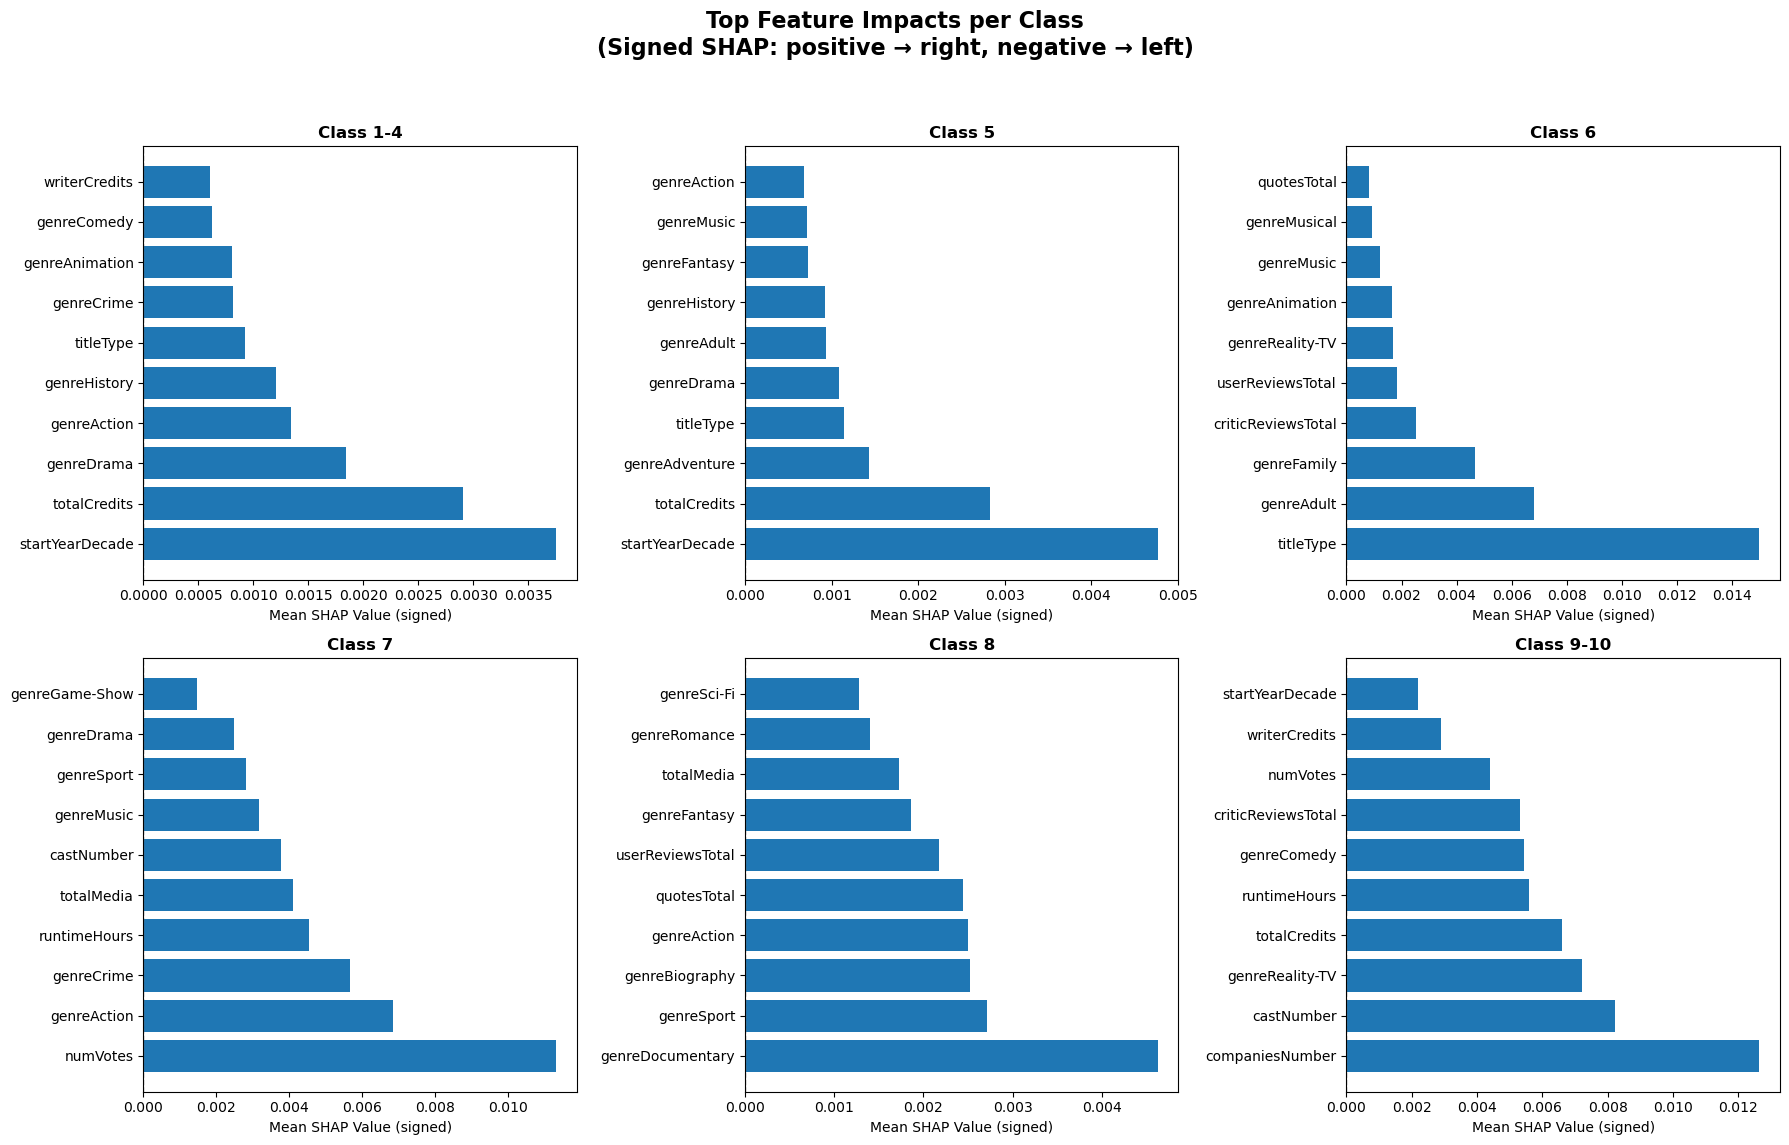

In [119]:
import matplotlib.pyplot as plt

# Correzione della mappa delle etichette
label_map = {
    0: "1-4",
    1: "5",
    2: "6",
    3: "7",
    4: "8",
    5: "9-10"
}

# Bar plot - Feature importance (senza valore assoluto)
plt.figure(figsize=(18, 12))
for class_idx in range(6):
    ax = plt.subplot(2, 3, class_idx + 1)
    
    # Calcola l'importanza media delle feature per la classe corrente (senza valore assoluto)
    class_shap = shap_values_formatted[class_idx].mean(axis=0)
    
    # Ordina le feature per importanza
    top_indices = np.argsort(class_shap)[-10:]  # Top 10 feature
    top_features = np.array(test_samples.columns)[top_indices]
    top_shap_values = class_shap[top_indices]
    
    # Usa colori distinti per valori positivi e negativi
    colors = ['#1f77b4' if val > 0 else '#d62728' for val in top_shap_values]
    
    # Bar plot orizzontale
    ax.barh(range(len(top_features)), top_shap_values, color=colors)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features, fontsize=10)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f"Class {label_map[class_idx]}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Mean SHAP Value (signed)", fontsize=10)
    ax.invert_yaxis()  # La feature più importante in alto

# Titolo generale e layout migliorato
plt.suptitle("Top Feature Impacts per Class\n(Signed SHAP: positive → right, negative → left)", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

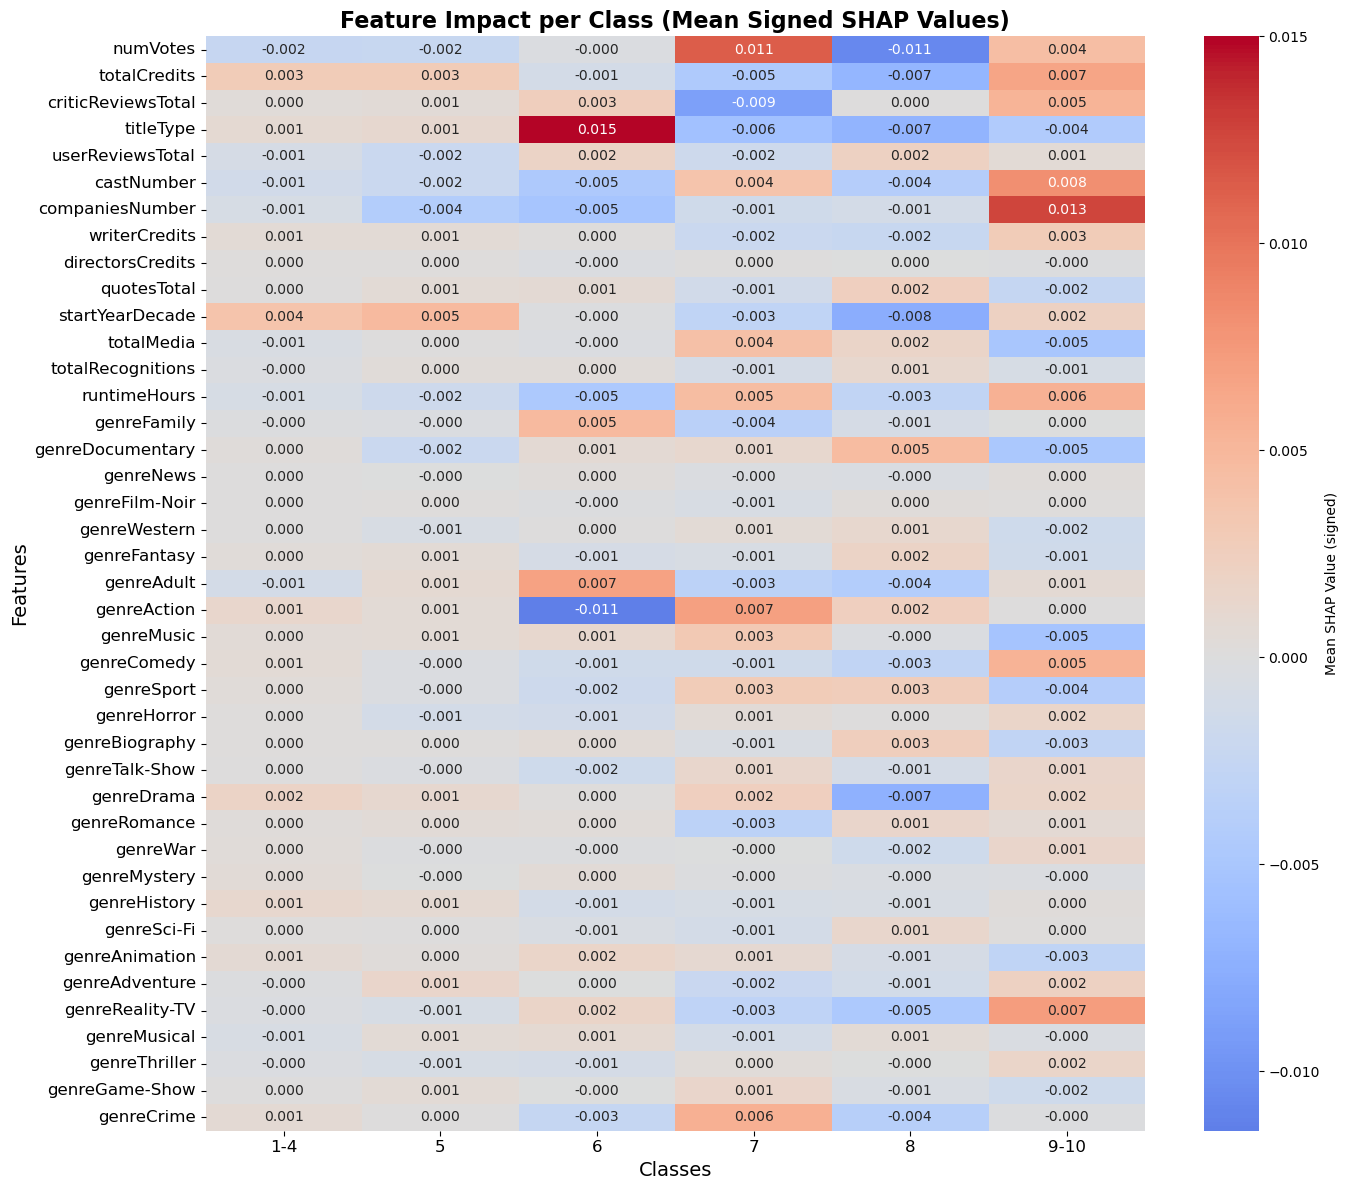

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correzione della mappa delle etichette
label_map = {
    0: "1-4",
    1: "5",
    2: "6",
    3: "7",
    4: "8",
    5: "9-10"
}

# Get feature names
feature_names = test_samples.columns if isinstance(test_samples, pd.DataFrame) else [f'Feature {i}' for i in range(test_samples.shape[1])]

# Build the matrix of mean (signed) SHAP values
mean_shap_matrix = np.array([
    shap_values_formatted[class_idx].mean(axis=0)  # average over the samples
    for class_idx in range(6)
]).T  # Transpose to shape (n_features, n_classes)

# Create a DataFrame for better readability
shap_df = pd.DataFrame(mean_shap_matrix, index=feature_names, columns=[label_map[i] for i in range(6)])

# Visualize with a heatmap (signed SHAP values)
plt.figure(figsize=(14, 12))
sns.heatmap(
    shap_df, 
    annot=True, 
    fmt=".3f", 
    cmap='coolwarm', 
    center=0, 
    cbar_kws={'label': 'Mean SHAP Value (signed)'}
)

# Miglioramento del layout e dei titoli
plt.title('Feature Impact per Class (Mean Signed SHAP Values)', fontsize=16, fontweight='bold')
plt.xlabel('Classes', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

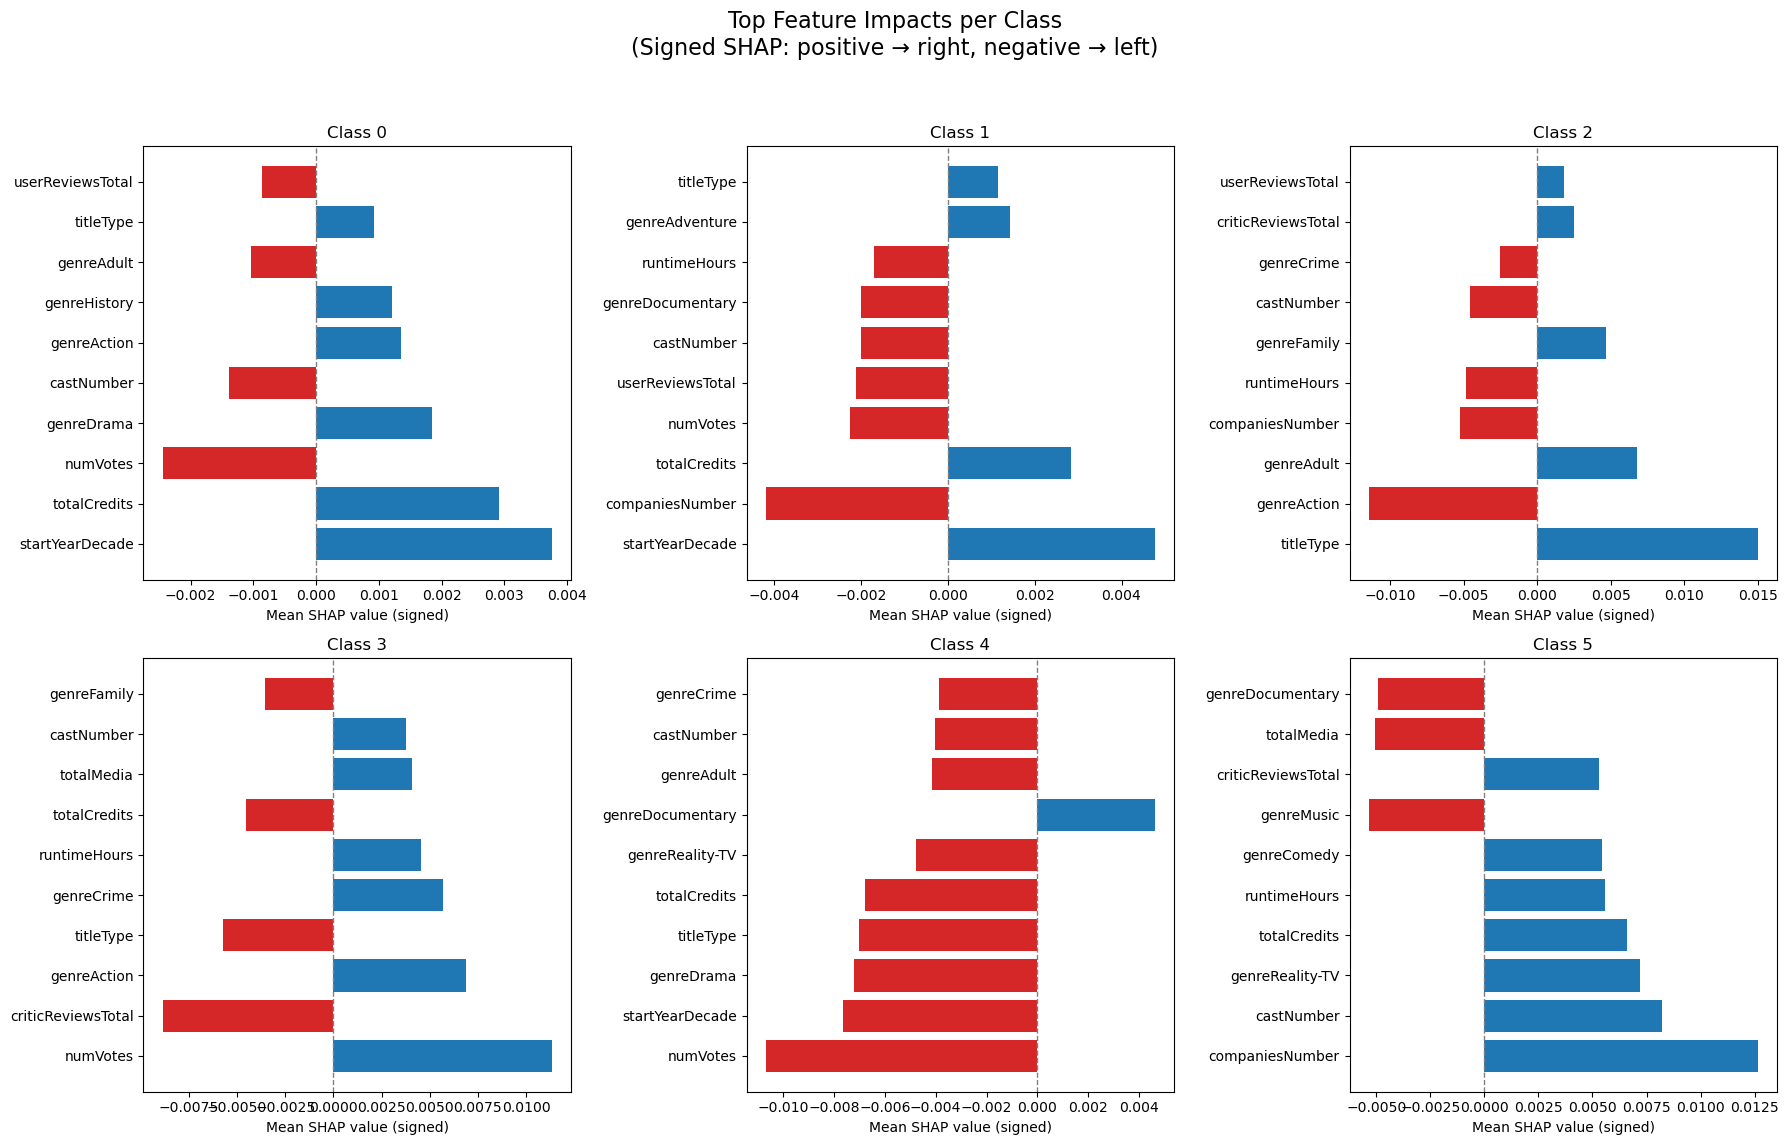

In [121]:
# Number of classes
num_classes = len(shap_values_formatted)
top_n = 10  # Number of top features to display

plt.figure(figsize=(18, 12))

for class_idx in range(num_classes):
    ax = plt.subplot(2, 3, class_idx + 1)

    # Get the signed mean SHAP values for this class
    class_shap = shap_values_formatted[class_idx].mean(axis=0)

    # Select top features by absolute SHAP value
    top_indices = np.argsort(np.abs(class_shap))[-top_n:]
    top_features = np.array(feature_names)[top_indices]
    top_shap_values = class_shap[top_indices]

    # Use blue for positive, red for negative
    colors = ['#1f77b4' if val > 0 else '#d62728' for val in top_shap_values]

    # Draw horizontal bar plot
    ax.barh(range(top_n), top_shap_values, color=colors)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'Class {class_idx}')
    ax.set_xlabel('Mean SHAP value (signed)')
    ax.invert_yaxis()  # Top feature appears at the top

plt.suptitle('Top Feature Impacts per Class\n(Signed SHAP: positive → right, negative → left)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


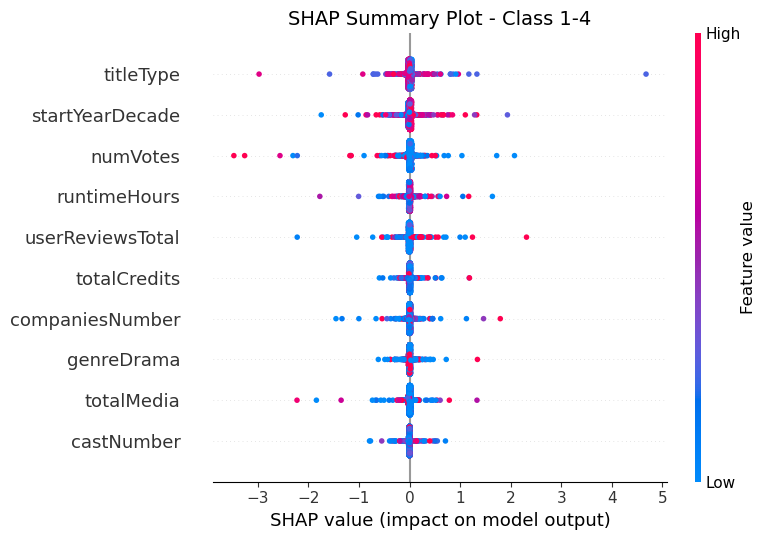

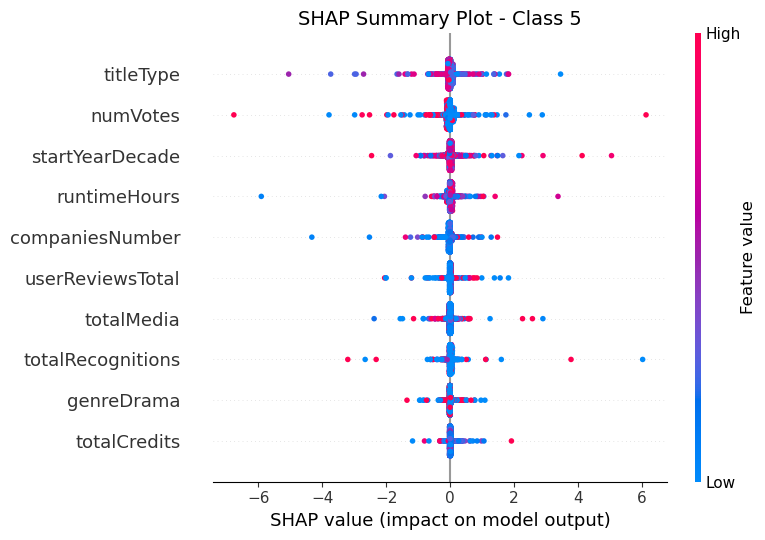

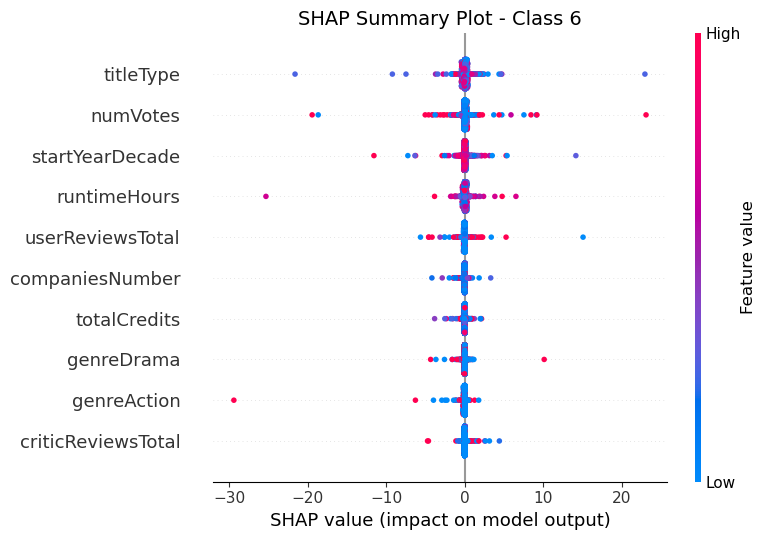

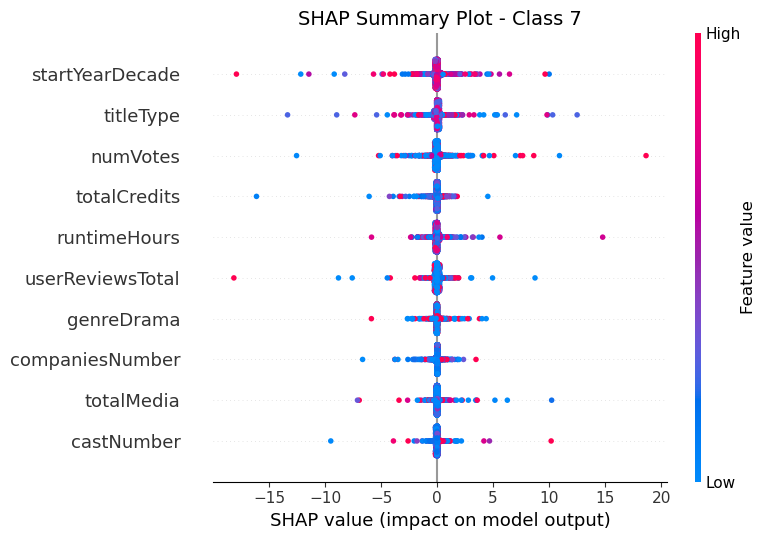

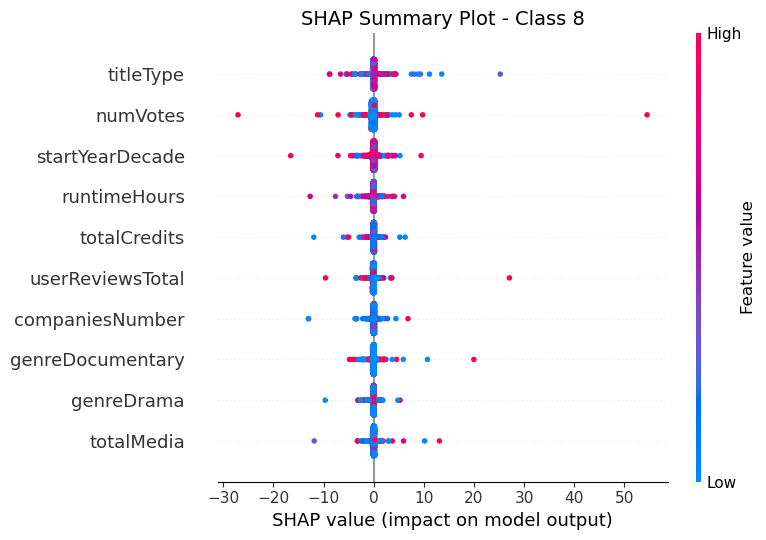

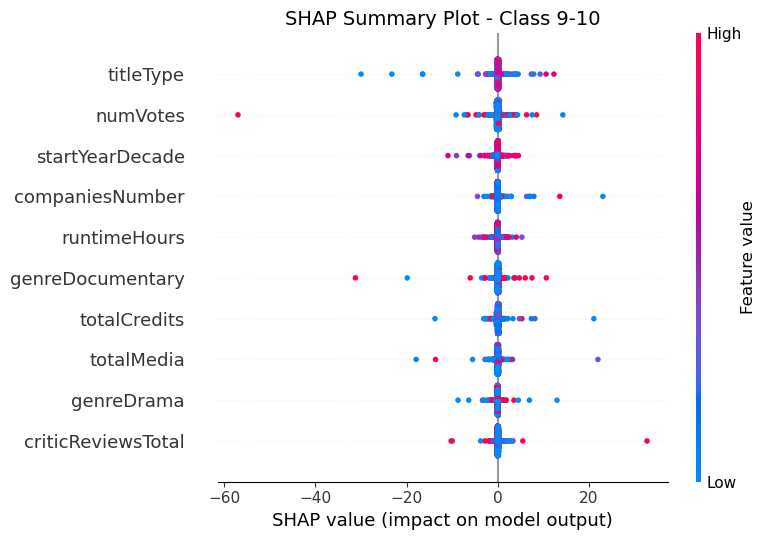

In [122]:
# Beeswarm plot for each class (Top 10 features only)

# Assicurati che test_samples sia un DataFrame con nomi delle colonne
if not isinstance(test_samples, pd.DataFrame):
    test_samples_df = pd.DataFrame(test_samples, columns=feature_names)
else:
    test_samples_df = test_samples

# Mostra solo le 10 feature più influenti per ogni classe
top_n = 10  # Numero di feature da mostrare

for class_idx in range(len(shap_values_formatted)):
    # Calcola l'importanza media assoluta delle feature per la classe corrente
    mean_abs_shap = np.abs(shap_values_formatted[class_idx]).mean(axis=0)
    
    # Ottieni gli indici delle top N feature
    top_indices = np.argsort(mean_abs_shap)[-top_n:]
    
    # Filtra le SHAP values e i valori delle feature per le top N feature
    shap_values_top = shap_values_formatted[class_idx][:, top_indices]
    features_top = test_samples_df.iloc[:, top_indices]
    
    # Crea il beeswarm plot per le top N feature
    plt.figure(figsize=(10, 6))  # Dimensioni più compatte
    shap.summary_plot(
        shap_values_top,          # SHAP values per le top N feature
        features=features_top,    # Valori delle feature corrispondenti
        feature_names=features_top.columns,  # Nomi delle feature
        show=False                # Sopprimi la visualizzazione immediata
    )
    plt.title(f"SHAP Summary Plot - Class {label_map[class_idx]}", fontsize=14)
    plt.tight_layout()
    plt.show()